# TP Python 2 : GeoPandas — Données vectorielles

**Géoinformatique II — Université de Lausanne**

---

In [6]:
# Importation des bibliothèques nécessaires
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

print(f"GeoPandas version : {gpd.__version__}")
print(f"Pandas version    : {pd.__version__}")

GeoPandas version : 1.1.3
Pandas version    : 2.2.3


---
## 1. GeoDataFrame — structure et géométries

Un `GeoDataFrame` est un tableau de données (comme un `DataFrame` Pandas)
auquel s'ajoute une colonne `geometry` contenant les géométries des entités.

### 1.1 Les types de géométries

| Type | Description | Exemple SIG |
|---|---|---|
| `Point` | Un emplacement (x, y) | Ville, station météo |
| `LineString` | Une séquence de points reliés | Route, rivière |
| `Polygon` | Une surface fermée | Commune, canton, pays |
| `MultiPolygon` | Plusieurs polygones pour une entité | Pays insulaires |


In [7]:
# Création d'un GeoDataFrame à partir de zéro
# (en pratique, on lit des fichiers, mais c'est utile pour comprendre la structure)
from shapely.geometry import Point, LineString, Polygon

# Quelques villes suisses avec leurs coordonnées WGS84
data = {
    'ville': ['Lausanne', 'Genève', 'Berne', 'Zurich', 'Bâle', 'Lugano'],
    'population': [139408, 203856, 133883, 428745, 179053, 63932],
    'altitude_m': [496, 375, 542, 408, 261, 273],
    'geometry': [
        Point(6.6323, 46.5197),
        Point(6.1432, 46.2044),
        Point(7.4458, 46.9480),
        Point(8.5417, 47.3769),
        Point(7.5886, 47.5596),
        Point(8.9530, 46.0037),
    ]
}

villes = gpd.GeoDataFrame(data, crs='EPSG:4326')   # WGS84

print(villes)
print()
print(f"CRS   : {villes.crs}")
print(f"Forme : {villes.shape}")
print(f"Types de géométrie : {villes.geom_type.unique()}")


      ville  population  altitude_m                geometry
0  Lausanne      139408         496  POINT (6.6323 46.5197)
1    Genève      203856         375  POINT (6.1432 46.2044)
2     Berne      133883         542   POINT (7.4458 46.948)
3    Zurich      428745         408  POINT (8.5417 47.3769)
4      Bâle      179053         261  POINT (7.5886 47.5596)
5    Lugano       63932         273   POINT (8.953 46.0037)

CRS   : EPSG:4326
Forme : (6, 4)
Types de géométrie : ['Point']


In [8]:
# --- Accès aux composantes d'une géométrie ---
lausanne_geom = villes.loc[0, 'geometry']    # objet Shapely Point
print(f"Géométrie : {lausanne_geom}")
print(f"Type      : {lausanne_geom.geom_type}")
print(f"Longitude : {lausanne_geom.x}")
print(f"Latitude  : {lausanne_geom.y}")

# Bounding box (emprise) du jeu de données entier
print(f"\nEmprise (bounds) : {villes.total_bounds}")
# [xmin, ymin, xmax, ymax]


Géométrie : POINT (6.6323 46.5197)
Type      : Point
Longitude : 6.6323
Latitude  : 46.5197

Emprise (bounds) : [ 6.1432 46.0037  8.953  47.5596]


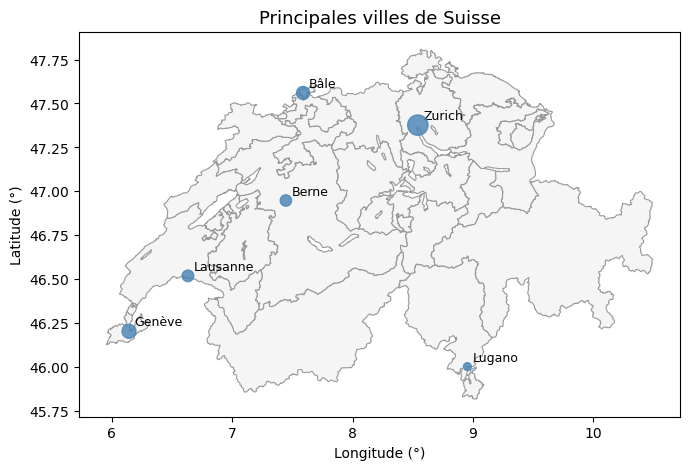

In [9]:
# --- Afficher les villes ---
fig, ax = plt.subplots(figsize=(7, 7))

# Charge le fond de carte (cantons suisses depuis tp1.gpkg)
cantons = gpd.read_file('tp1.gpkg', layer='Cantons').to_crs('EPSG:4326')

# Affiche les contours des cantons comme fond de carte
cantons.plot(ax=ax, color='#f5f5f5', edgecolor='#999', linewidth=0.8)

# Affiche les villes avec taille proportionnelle à la population
villes.plot(ax=ax, markersize=villes['population'] / 2000,
            color='steelblue', alpha=0.8, zorder=5)

# Étiquettes
for _, row in villes.iterrows():
    ax.annotate(row['ville'], xy=(row.geometry.x, row.geometry.y),
                xytext=(4, 4), textcoords='offset points', fontsize=9)

ax.set_title('Principales villes de Suisse', fontsize=13)
ax.set_xlabel('Longitude (°)')
ax.set_ylabel('Latitude (°)')
plt.tight_layout()
plt.show()

### 1.2 Chargement de données réelles

En pratique, on lit le plus souvent des fichiers existants :
- **Shapefile** (`.shp`) : format propriétaire Esri, très répandu
- **GeoJSON** (`.geojson`) : format texte ouvert, idéal pour le web
- **GeoPackage** (`.gpkg`) : format ouvert et moderne recommandé par l'OGC

Les deux méthodes ci-dessous donnent le même résultat :
```python
gdf = gpd.read_file("mon_fichier.shp")
gdf = gpd.read_file("http://exemple.com/donnees.geojson")
```


In [10]:
# Chargement des données cantonales depuis tp1.gpkg
cantons = gpd.read_file('tp1.gpkg', layer='Cantons')

# Ajout des données démographiques (population 2023, source : OFS)
pop_cantons = {
    'ZH': 1620800, 'BE': 1057400, 'LU': 432600, 'UR':   37400,
    'SZ':  166700, 'OW':   39100, 'NW':  43900, 'GL':   40900,
    'ZG':  131500, 'FR':  341700, 'SO': 280000, 'BS':  183000,
    'BL':  299100, 'SH':   84600, 'AR':  56400, 'AI':   16400,
    'SG':  520700, 'GR':  201000, 'AG': 718100, 'TG':  292600,
    'TI':  360300, 'VD':  867200, 'VS': 350600, 'NE':  176800,
    'GE':  509700, 'JU':   73600,
}
cantons['population'] = cantons['AK'].map(pop_cantons)
cantons['superficie_km2'] = cantons['area'] / 1e6

print("Colonnes disponibles :")
print(cantons.columns.tolist())
print()
print("5 premiers cantons :")
cantons.head()

Colonnes disponibles :
['KT', 'AK', 'NAME', 'area', 'geometry', 'population', 'superficie_km2']

5 premiers cantons :


,KT,AK,NAME,area,geometry,population,superficie_km2
0,1,ZH,Z�rich,1.661120e+09,"MULTIPOLYGON (((689073 283025, 689615 283093, ...",1620800,1661.120100
1,2,BE,Bern,5.840584e+09,"MULTIPOLYGON (((575335 196135, 576162 196492, ...",1057400,5840.584069
2,3,LU,Luzern,1.429278e+09,"MULTIPOLYGON (((675328 213188, 676178 212945, ...",432600,1429.277707
3,4,UR,Uri,1.057806e+09,"MULTIPOLYGON (((689986 200836, 690205 200840, ...",37400,1057.805516
4,5,SZ,Schwyz,8.517961e+08,"MULTIPOLYGON (((713825 230780, 714967 230597, ...",166700,851.796063


---
## 2. Requêtes attributaires

La sélection et le filtrage des données est l'une des opérations les plus
fréquentes en géomatique. GeoPandas hérite des mécanismes de Pandas.

### 2.1 Sélection avec `.loc` et `.iloc`

- `.loc[lignes, colonnes]` : sélection par **étiquettes** (noms de colonnes, index)
- `.iloc[lignes, colonnes]` : sélection par **position** (numéros entiers)


In [11]:
# .iloc — sélection par position
print("Première ligne (iloc[0]) :")
print(cantons.iloc[0])
print()
print("Lignes 0 à 4, colonnes 0 à 4 :")
print(cantons.iloc[0:5, 0:5])

Première ligne (iloc[0]) :
KT                                                                1
AK                                                               ZH
NAME                                                         Z�rich
area                                                  1661120099.56
geometry          MULTIPOLYGON (((689073 283025, 689615 283093, ...
population                                                  1620800
superficie_km2                                            1661.1201
Name: 0, dtype: object

Lignes 0 à 4, colonnes 0 à 4 :
   KT  AK    NAME          area  \
0   1  ZH  Z�rich  1.661120e+09   
1   2  BE    Bern  5.840584e+09   
2   3  LU  Luzern  1.429278e+09   
3   4  UR     Uri  1.057806e+09   
4   5  SZ  Schwyz  8.517961e+08   

                                            geometry  
0  MULTIPOLYGON (((689073 283025, 689615 283093, ...  
1  MULTIPOLYGON (((575335 196135, 576162 196492, ...  
2  MULTIPOLYGON (((675328 213188, 676178 212945, ...  
3  MULTIPOL

In [12]:
# .loc — sélection par étiquettes
print("Colonnes 'NAME' et 'population' pour les 5 premiers cantons :")
print(cantons.loc[0:4, ['NAME', 'population']])

Colonnes 'NAME' et 'population' pour les 5 premiers cantons :
     NAME  population
0  Z�rich     1620800
1    Bern     1057400
2  Luzern      432600
3     Uri       37400
4  Schwyz      166700


In [13]:
# Sélection par condition booléenne
# (la plus courante en pratique)

# Cantons avec plus de 400 000 habitants
grands_cantons = cantons[cantons['population'] > 400_000]

# Petits cantons (moins de 50 000 habitants)
petits_cantons = cantons[cantons['population'] < 50_000]

# Cantons à forte densité (> 500 hab/km²)
cantons_denses = cantons[
    cantons['population'] / cantons['superficie_km2'] > 500
]

print(f"Cantons > 400 000 hab.       : {len(grands_cantons)}")
print(f"Cantons < 50 000 hab.        : {len(petits_cantons)}")
print(f"Cantons denses (> 500/km²)   : {len(cantons_denses)}")
print(cantons_denses[['NAME', 'AK', 'population', 'superficie_km2']])

Cantons > 400 000 hab.       : 7
Cantons < 50 000 hab.        : 5
Cantons denses (> 500/km²)   : 6
                NAME  AK  population  superficie_km2
0             Z�rich  ZH     1620800     1661.120100
8                Zug  ZG      131500      207.316013
11       Basel-Stadt  BS      183000       36.812779
12  Basel-Landschaft  BL      299100      517.885952
18            Aargau  AG      718100     1395.007222
24            Gen�ve  GE      509700      245.812694


### 2.2 Requêtes avec `.query()`

La méthode `.query()` accepte une expression sous forme de chaîne de caractères,
ce qui la rend plus lisible pour des conditions complexes.


In [14]:
# Équivalents avec .query()
grands_cantons_q  = cantons.query("population > 400_000")
petits_cantons_q  = cantons.query("population < 50_000")
cantons_denses_q  = cantons.query("population / superficie_km2 > 500")

# Variable externe dans une query (préfixe @)
seuil_pop = 200_000
cantons_moyens = cantons.query("population > @seuil_pop and population < 500_000")
print(f"Cantons entre 200 000 et 500 000 hab. : {len(cantons_moyens)}")
print(cantons_moyens[['NAME', 'AK', 'population']].sort_values('population', ascending=False))

Cantons entre 200 000 et 500 000 hab. : 8
                NAME  AK  population
2             Luzern  LU      432600
20            Ticino  TI      360300
22            Valais  VS      350600
9           Fribourg  FR      341700
12  Basel-Landschaft  BL      299100
19           Thurgau  TG      292600
10         Solothurn  SO      280000
17        Graub�nden  GR      201000


---
## 3. Jointures

Les jointures permettent de **combiner deux tables** en fonction d'un attribut commun
(jointure attributaire) ou d'une relation spatiale (jointure spatiale).

### 3.1 Jointure attributaire — `merge()`

Similaire à un SQL JOIN ou à la jointure de table dans QGIS.


In [15]:
# --- Création d'une table de données supplémentaires ---
# Données de bien-être cantonal (exemples illustratifs)
idh_data = pd.DataFrame({
    'AK': ['ZH', 'BE', 'VD', 'GE', 'BS', 'TI', 'VS', 'FR', 'AG', 'SG'],
    'idh_cantonal': [0.955, 0.942, 0.948, 0.962, 0.959,
                     0.932, 0.926, 0.918, 0.939, 0.934],
    'esperance_vie': [84.1, 83.8, 84.3, 84.5, 84.2,
                      83.5, 83.2, 83.0, 83.7, 83.4]
})

print("Table IDH cantonal :")
print(idh_data)

Table IDH cantonal :
   AK  idh_cantonal  esperance_vie
0  ZH         0.955           84.1
1  BE         0.942           83.8
2  VD         0.948           84.3
3  GE         0.962           84.5
4  BS         0.959           84.2
5  TI         0.932           83.5
6  VS         0.926           83.2
7  FR         0.918           83.0
8  AG         0.939           83.7
9  SG         0.934           83.4


In [16]:
# --- Jointure attributaire ---
# On joint le GeoDataFrame 'cantons' avec la table 'idh_data'
# La colonne de jointure est 'AK' dans les deux tables
cantons_idh = cantons.merge(
    idh_data,
    on='AK',        # colonne de clé commune
    how='left'      # garde tous les cantons, même sans IDH
)

print(f"\nRésultat de la jointure : {cantons_idh.shape}")
print(cantons_idh[['NAME', 'AK', 'population', 'idh_cantonal', 'esperance_vie']].dropna().head(10))


Résultat de la jointure : (26, 9)
           NAME  AK  population  idh_cantonal  esperance_vie
0        Z�rich  ZH     1620800         0.955           84.1
1          Bern  BE     1057400         0.942           83.8
9      Fribourg  FR      341700         0.918           83.0
11  Basel-Stadt  BS      183000         0.959           84.2
16   St. Gallen  SG      520700         0.934           83.4
18       Aargau  AG      718100         0.939           83.7
20       Ticino  TI      360300         0.932           83.5
21         Vaud  VD      867200         0.948           84.3
22       Valais  VS      350600         0.926           83.2
24       Gen�ve  GE      509700         0.962           84.5


### 3.2 Jointure spatiale — `sjoin()`

La jointure spatiale associe des entités en fonction de leur **relation
géométrique** (intersection, contenance, proximité).

> 🔗 **Parallèle QGIS** : outil *Joindre les attributs par localisation* ou
> *Sélection par localisation*.


In [18]:
# --- Exemple de jointure spatiale ---
# On veut savoir dans quel canton se trouve chaque ville de notre liste

# Notre GeoDataFrame de villes (déjà créé plus haut)
print("Villes :")
print(villes[['ville', 'geometry']])
print()

# GeoDataFrame des cantons en WGS84 (même CRS que villes)
# On renomme la population cantonale pour éviter le conflit avec la population des villes
cantons_wgs84 = cantons.to_crs(epsg=4326).rename(columns={'population': 'pop_canton'})

# sjoin : pour chaque ville, on cherche le canton qui la contient
villes_dans_cantons = gpd.sjoin(
    villes,                                                         # GeoDataFrame gauche (points)
    cantons_wgs84[['NAME', 'AK', 'pop_canton', 'geometry']],       # GeoDataFrame droit (polygones)
    how='left',                                                     # garde toutes les villes
    predicate='within'                                              # relation spatiale : point dans polygone
)

print("Résultat de la jointure spatiale :")
print(villes_dans_cantons[['ville', 'NAME', 'AK', 'pop_canton']])

Villes :
      ville                geometry
0  Lausanne  POINT (6.6323 46.5197)
1    Genève  POINT (6.1432 46.2044)
2     Berne   POINT (7.4458 46.948)
3    Zurich  POINT (8.5417 47.3769)
4      Bâle  POINT (7.5886 47.5596)
5    Lugano   POINT (8.953 46.0037)

Résultat de la jointure spatiale :
      ville         NAME  AK  pop_canton
0  Lausanne         Vaud  VD      867200
1    Genève       Gen�ve  GE      509700
2     Berne         Bern  BE     1057400
3    Zurich       Z�rich  ZH     1620800
4      Bâle  Basel-Stadt  BS      183000
5    Lugano       Ticino  TI      360300


---
## 4. Reprojection — `.to_crs()`

Le **CRS (Coordinate Reference System)** définit comment les coordonnées
sont ancrées sur la Terre. Il est crucial de s'assurer que toutes les
couches utilisées partagent le même CRS.

| CRS | Code EPSG | Utilisation |
|---|---|---|
| WGS84 (géographique) | 4326 | GPS, données mondiales |
| Swiss LV95 / MN95 | 2056 | Données suisses (swisstopo) |
| Web Mercator | 3857 | Tuiles web, OpenStreetMap |
| UTM 32N | 32632 | Europe centrale (mesures métriques) |

**Important** : `.area`, `.length` et `.distance()` retournent des valeurs
dans l'unité du CRS. En WGS84 (degrés), ces valeurs n'ont pas de sens
physique direct — il faut d'abord reprojeter en système métrique.


In [19]:
# --- Impact du CRS sur les mesures ---
# Exemple avec le canton de Vaud
cantons_wgs84 = gpd.read_file('tp1.gpkg', layer='Cantons').to_crs(epsg=4326)
vaud = cantons_wgs84[cantons_wgs84['AK'] == 'VD'].copy()

# Superficie en WGS84 (degrés² — peu interprétable !)
area_wgs84 = vaud.geometry.area.values[0]
print(f"Superficie WGS84 (degrés²)    : {area_wgs84:.6f}")

# Reprojection en MN95 / LV95 (système métrique officiel suisse)
vaud_mn95 = vaud.to_crs(epsg=2056)
area_mn95_km2 = vaud_mn95.geometry.area.values[0] / 1e6
print(f"Superficie MN95  (km²)        : {area_mn95_km2:,.0f} km²")
print(f"(Superficie réelle Vaud ≈ 3 212 km²)")

Superficie WGS84 (degrés²)    : 0.331293
Superficie MN95  (km²)        : 2,823 km²
(Superficie réelle Vaud ≈ 3 212 km²)


/tmp/ipykernel_62188/929141853.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area_wgs84 = vaud.geometry.area.values[0]


In [20]:
# --- Reprojection de notre couche de villes suisses ---
print("CRS initial :", villes.crs)

# Reprojection en MN95 (Swiss LV95) — système officiel suisse
villes_mn95 = villes.to_crs(epsg=2056)
print("CRS après reprojection :", villes_mn95.crs)
print()

# Les coordonnées ont changé !
print("Coordonnées WGS84  (Lausanne) :",
      villes.loc[0, 'geometry'].x, villes.loc[0, 'geometry'].y)
print("Coordonnées MN95   (Lausanne) :",
      round(villes_mn95.loc[0, 'geometry'].x),
      round(villes_mn95.loc[0, 'geometry'].y))


CRS initial : EPSG:4326
CRS après reprojection : EPSG:2056

Coordonnées WGS84  (Lausanne) : 6.6323 46.5197
Coordonnées MN95   (Lausanne) : 2538124 1152363


In [21]:
# --- Calcul de distances après reprojection ---
# Calcul de la distance entre Lausanne et Zurich (en km)
villes_mn95 = villes.to_crs(epsg=2056)

lausanne_pt = villes_mn95[villes_mn95['ville'] == 'Lausanne'].geometry.values[0]
zurich_pt   = villes_mn95[villes_mn95['ville'] == 'Zurich'].geometry.values[0]

distance_m = lausanne_pt.distance(zurich_pt)
print(f"Distance Lausanne–Zurich (MN95) : {distance_m / 1000:.1f} km")
print("(Distance réelle à vol d'oiseau : ≈ 175 km)")


Distance Lausanne–Zurich (MN95) : 173.8 km
(Distance réelle à vol d'oiseau : ≈ 175 km)


---
## 5. Cartographie choroplèthe

Une **carte choroplèthe** colore les entités géographiques en fonction de la
valeur d'un attribut numérique. C'est l'un des types de cartes thématiques
les plus courants en géomatique.

### 5.1 Carte choroplèthe simple avec GeoPandas


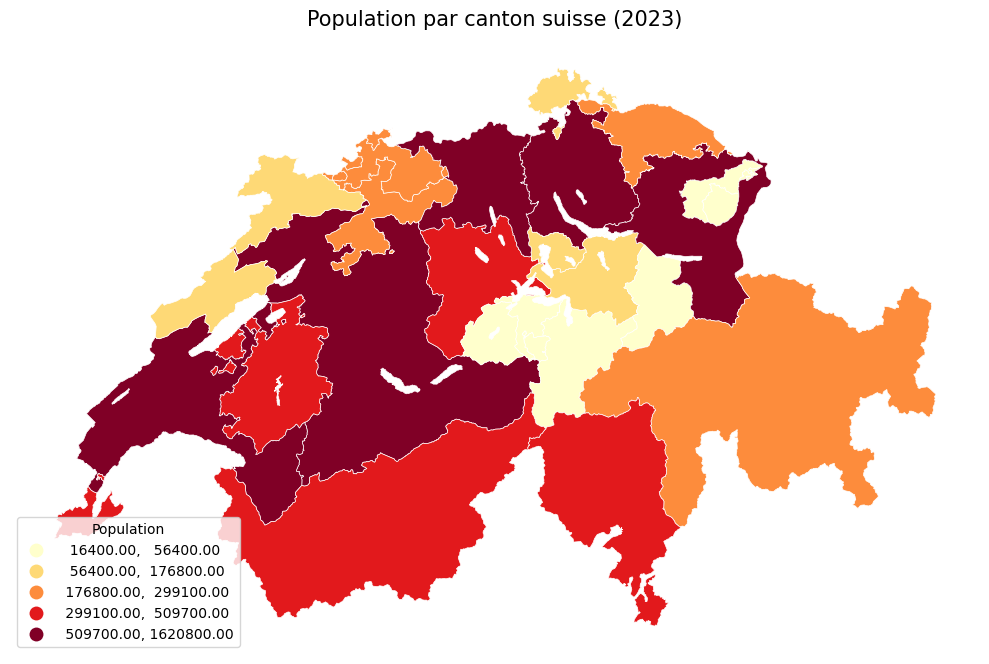

In [22]:
pop_cantons = {
    'ZH': 1620800, 'BE': 1057400, 'LU': 432600, 'UR':   37400,
    'SZ':  166700, 'OW':   39100, 'NW':  43900, 'GL':   40900,
    'ZG':  131500, 'FR':  341700, 'SO': 280000, 'BS':  183000,
    'BL':  299100, 'SH':   84600, 'AR':  56400, 'AI':   16400,
    'SG':  520700, 'GR':  201000, 'AG': 718100, 'TG':  292600,
    'TI':  360300, 'VD':  867200, 'VS': 350600, 'NE':  176800,
    'GE':  509700, 'JU':   73600,
}
cantons = gpd.read_file('tp1.gpkg', layer='Cantons')
cantons['population'] = cantons['AK'].map(pop_cantons)

fig, ax = plt.subplots(figsize=(10, 8))

cantons.plot(
    ax=ax,
    column='population',           # attribut à visualiser
    cmap='YlOrRd',                 # palette de couleurs
    scheme='quantiles',            # méthode de discrétisation
    k=5,                           # nombre de classes
    legend=True,
    legend_kwds={
        'title': 'Population',
        'loc': 'lower left',
    },
    edgecolor='white',
    linewidth=0.5,
    missing_kwds={'color': 'lightgrey'}
)

ax.set_title('Population par canton suisse (2023)', fontsize=15, pad=10)
ax.set_facecolor('#c7e9f1')    # couleur de fond (eau)
ax.set_axis_off()              # masque les axes
plt.tight_layout()
plt.show()

### 5.2 Méthodes de discrétisation

Le choix de la **méthode de classification** est crucial : elle influence
fortement la perception de la carte.

| Méthode (`scheme=`) | Description |
|---|---|
| `'quantiles'` | Classes avec le même nombre d'entités |
| `'equal_interval'` | Classes avec le même intervalle de valeurs |
| `'natural_breaks'` (Jenks) | Minimise la variance intra-classe |
| `'fisher_jenks'` | Variante plus stable de Jenks |
| `'std_mean'` | Classes basées sur l'écart-type |


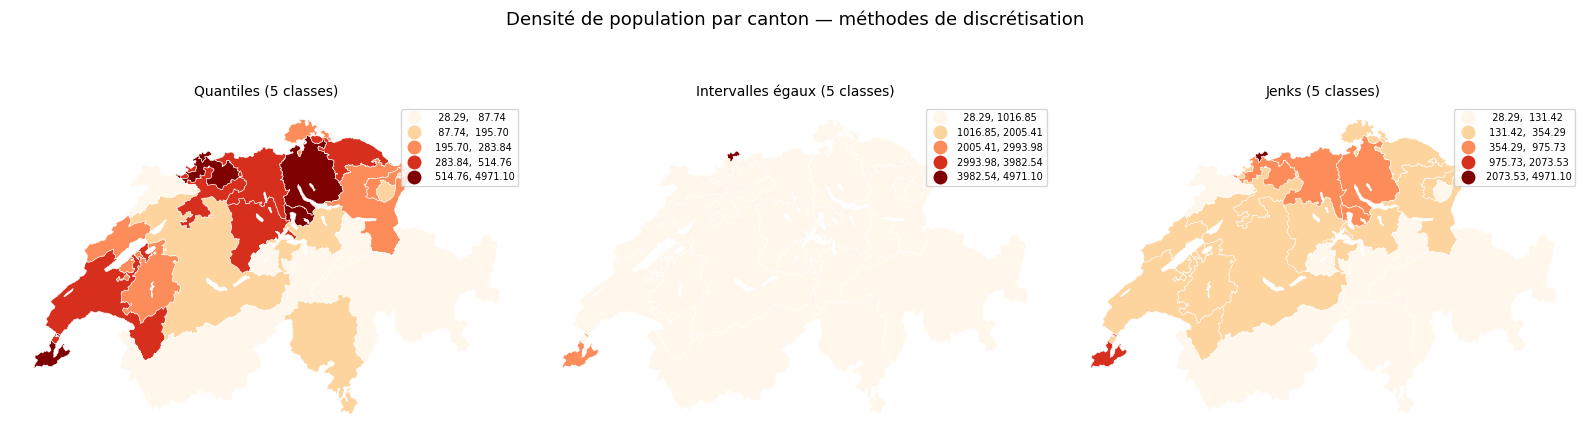

In [23]:
# --- Comparaison de méthodes de discrétisation ---
# cantons déjà chargé avec population dans la cellule précédente
cantons['superficie_km2'] = cantons['area'] / 1e6
cantons['densite'] = cantons['population'] / cantons['superficie_km2']

methodes = ['quantiles', 'equal_interval', 'natural_breaks']
titres   = ['Quantiles (5 classes)', 'Intervalles égaux (5 classes)', 'Jenks (5 classes)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, methode, titre in zip(axes, methodes, titres):
    cantons.plot(
        ax=ax, column='densite',
        cmap='OrRd', scheme=methode, k=5,
        legend=True, legend_kwds={'fontsize': 7},
        edgecolor='white', linewidth=0.4,
        missing_kwds={'color': 'lightgrey'}
    )
    ax.set_title(titre, fontsize=10)
    ax.set_axis_off()

plt.suptitle('Densité de population par canton — méthodes de discrétisation', fontsize=13)
plt.tight_layout()
plt.show()

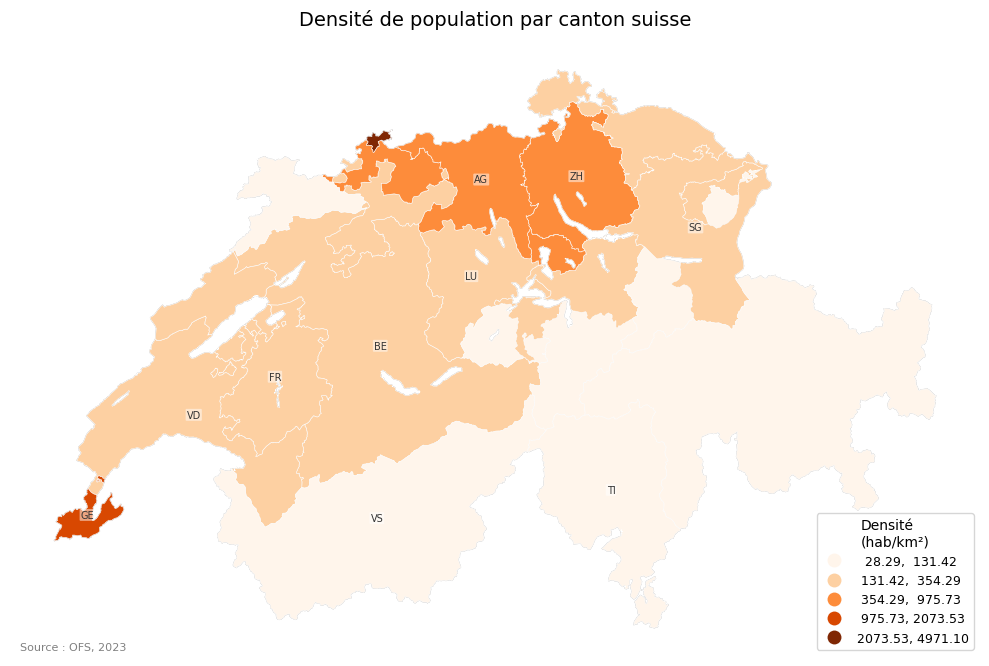

In [24]:
# --- Carte choroplèthe avec éléments cartographiques ---
# cantons déjà chargé avec population et densite dans les cellules précédentes

fig, ax = plt.subplots(figsize=(10, 9))

# Fond de carte
cantons.plot(ax=ax, color='#f0f0f0', edgecolor='#aaa', linewidth=0.5)

# Choroplèthe
cantons.plot(
    ax=ax,
    column='densite',
    cmap='Oranges',
    scheme='natural_breaks', k=5,
    legend=True,
    legend_kwds={
        'title': 'Densité\n(hab/km²)',
        'loc': 'lower right',
        'fontsize': 9,
        'title_fontsize': 10,
    },
    edgecolor='white', linewidth=0.4,
    missing_kwds={'color': '#cccccc', 'label': 'Données manquantes'}
)

# Étiquettes pour les cantons les plus peuplés
for _, row in cantons.iterrows():
    if row['population'] > 300_000:
        ax.annotate(row['AK'],
                    xy=(row.geometry.centroid.x, row.geometry.centroid.y),
                    ha='center', fontsize=7, color='#333',
                    bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.5, lw=0))

ax.set_title('Densité de population par canton suisse', fontsize=14, pad=12)
ax.set_axis_off()

# Note de source
ax.annotate('Source : OFS, 2023',
            xy=(0.01, 0.01), xycoords='axes fraction',
            fontsize=8, color='grey')

plt.tight_layout()
plt.show()

---
## 6. Export — shapefile et GeoJSON

Une fois les données traitées, il faut souvent les **sauvegarder** dans un
format standard pour les partager ou les ouvrir dans un autre logiciel.


In [25]:
import os

# Création d'un dossier de sortie
os.makedirs("sortie", exist_ok=True)

# --- Export en Shapefile ---
# Attention : les shapefiles tronquent les noms de colonnes à 10 caractères
# et ne supportent pas les caractères spéciaux dans les attributs.
cantons.to_file("sortie/cantons.shp")
print("Shapefile sauvegardé : sortie/cantons.shp")

# --- Export en GeoJSON ---
# GeoJSON est plus pratique : noms de colonnes sans limite, un seul fichier
cantons.to_file("sortie/cantons.geojson", driver='GeoJSON')
print("GeoJSON sauvegardé  : sortie/cantons.geojson")

# --- Export en GeoPackage (recommandé) ---
# Format ouvert, un seul fichier, supporte plusieurs couches
cantons.to_file("sortie/suisse.gpkg", layer='cantons', driver='GPKG')
villes.to_file("sortie/suisse.gpkg", layer='villes_suisse', driver='GPKG')
print("GeoPackage sauvegardé : sortie/suisse.gpkg (2 couches)")

Shapefile sauvegardé : sortie/cantons.shp
GeoJSON sauvegardé  : sortie/cantons.geojson
GeoPackage sauvegardé : sortie/suisse.gpkg (2 couches)


/tmp/ipykernel_62188/2881351200.py:9: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  cantons.to_file("sortie/cantons.shp")
/home/jsoutter/anaconda3/envs/landslide/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'superficie_km2' to 'superficie'
  ogr_write(
/home/jsoutter/anaconda3/envs/landslide/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 1661120099.5599999 of field area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/jsoutter/anaconda3/envs/landslide/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 5840584069.2200003 of field area of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
/home/jsoutter/anaconda3/envs/landslide/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value 1429277707 

In [26]:
# --- Vérification : relire un fichier exporté ---
cantons_relu = gpd.read_file("sortie/cantons.geojson")
print(f"Fichier relu : {cantons_relu.shape[0]} entités, CRS = {cantons_relu.crs}")

# --- Export d'une sélection avec reprojection ---
# Exemple : exporter les cantons en MN95/LV95 (système officiel suisse)
cantons_mn95 = cantons.to_crs(epsg=2056)
cantons_mn95.to_file("sortie/cantons_mn95.gpkg", driver='GPKG')
print("Export MN95 sauvegardé.")

Fichier relu : 26 entités, CRS = EPSG:21781
Export MN95 sauvegardé.
